# 04 — AI 모델 작동 시연 (Demo Prediction)

> 학습된 최종 모델을 활용하여 실제 예측 및 시나리오 기반 시뮬레이션을 수행합니다.  
> 이 노트북은 **ONE CELL 실행**으로 전체 예측 흐름을 재현할 수 있도록 구성되어 있습니다.

## 전제 조건

- 03_training_evaluation.ipynb를 최소 1회 실행해야 합니다.
- 아래 파일이 생성되어 있어야 합니다:

  - model/final_catboost_multi.cbm  
  - model/metadata.json  
  - data/processed/processed.csv  

## 구성

1) 모델 및 메타데이터 로드  
   - final_catboost_multi.cbm  
   - metadata.json  

2) 단일 입력 예측  
   - 중앙값 기반 입력  
   - Leaf / Root TPC, TFC 동시 예측  

3) 예측 구간 추정 (선택)  
   - 90% 예측 구간 계산 및 시각화  

4) 시나리오 기반 시뮬레이션  
   - 온도 범위: 18 ~ 28℃  
   - CO₂ 시나리오: 450 / 800 / 1150 ppm  

5) 시각화  
   - 타깃 변수별 라인 플롯  
   - 온도 × CO₂ 비교 그래프  
   - 기후 변수 변화에 따른 민감도 분석  

## 실행 방식

- 전체 코드는 **하나의 셀에서 실행 가능 (ONE CELL)**  
- 별도의 단계 실행 없이 전체 흐름을 재현할 수 있도록 설계됨  

## 목적

- 학습된 모델이 실제 환경 변화에 어떻게 반응하는지 확인  
- 기후 조건 변화에 따른 기능성 성분 변동 패턴 해석  
- 데이터 기반 작물 관리 및 의사결정 지원 가능성 평가  

단일 입력 예측 (중앙값 + 있으면 90% PI)


,Leaf_TPC,Root_TPC,Leaf_TFC,Root_TFC,Leaf_TPC_lo90,Leaf_TPC_hi90,Root_TPC_lo90,Root_TPC_hi90,Leaf_TFC_lo90,Leaf_TFC_hi90,Root_TFC_lo90,Root_TFC_hi90
0,7.839081,5.326063,6.628746,0.658864,7.525379,7.558799,5.338403,5.633325,6.494719,6.88217,0.714982,0.725372



스윕 표 일부(상위 6행):


,Temp,CO2ppm,Leaf_TPC,Root_TPC,Leaf_TFC,Root_TFC
0,18,450,7.839081,5.326063,6.628746,0.658864
1,19,450,7.839081,5.326063,6.628746,0.658864
2,20,450,7.839081,5.326063,6.628746,0.658864
3,21,450,7.839081,5.326063,6.628746,0.658864
4,22,450,7.839081,5.326063,6.628746,0.658864


/var/folders/gc/lnz6gh2j4lxftvc94s3bn1w00000gn/T/ipykernel_14973/3884192485.py:102: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.legend(title="CO₂ppm"); plt.tight_layout(); plt.show()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


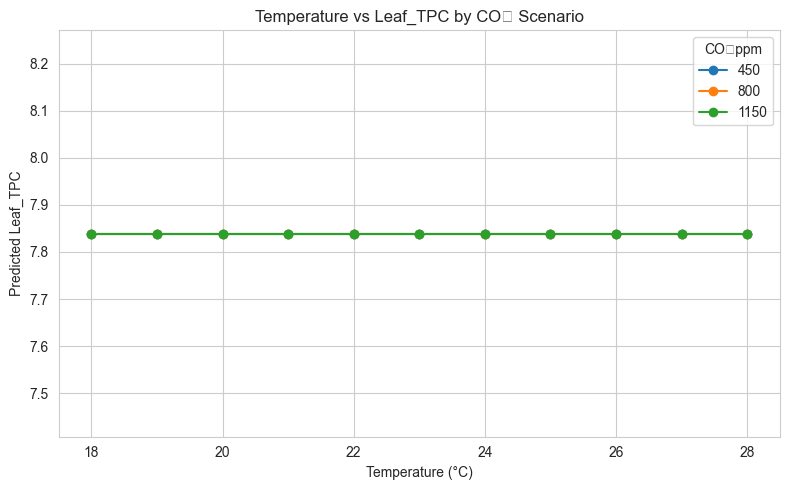

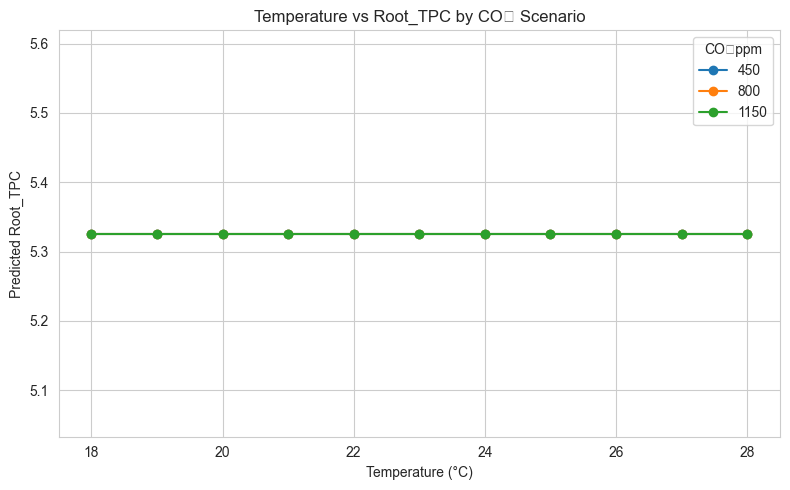

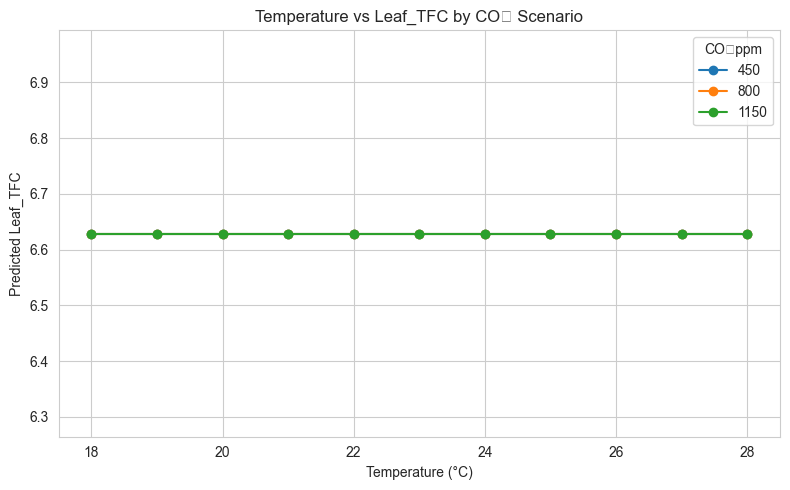

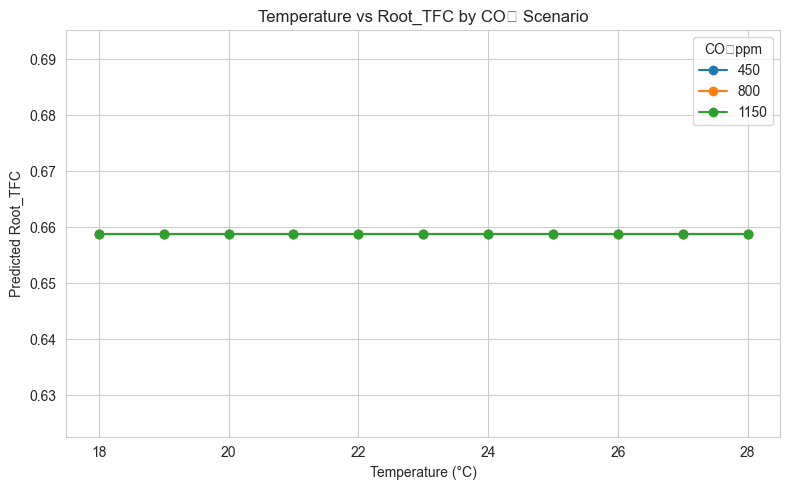

In [1]:
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from catboost import CatBoostRegressor
sns.set_style("whitegrid")
import matplotlib as mpl
import matplotlib.pyplot as plt

# ----------------------------
# 0) 필수 파일 체크 & 로드
# ----------------------------
META_P = "model/metadata.json"
MODEL_P = "model/final_catboost_multi.cbm"
PROC_P  = "data/processed/processed.csv"

assert os.path.exists(META_P),  "metadata.json이 없음. 03 노트북을 먼저 실행."
assert os.path.exists(MODEL_P), "final_catboost_multi.cbm이 없음. 03 노트북을 먼저 실행."
assert os.path.exists(PROC_P),  "processed.csv가 없음. 01/03 노트북을 먼저 실행."

with open(META_P, "r", encoding="utf-8") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
targets = meta.get("target_cols") or meta.get("target_names") \
          or ["Leaf_TPC","Root_TPC","Leaf_TFC","Root_TFC"]

# 최종 모델 로드
final_model = CatBoostRegressor()
final_model.load_model(MODEL_P)

# processed.csv에서 고정 변수들의 대표값을 가져와 데모에 활용
dfp = pd.read_csv(PROC_P)
feat_means = dfp[["TChl","Car","Dio-RC","Eto-RC","Fv-Fm"]].mean(numeric_only=True).to_dict()

# ----------------------------
# 1) 유틸 함수들
# ----------------------------
def month_to_sin_cos(m):
    return np.sin(2*np.pi*m/12), np.cos(2*np.pi*m/12)

def make_input_row(temp, humid, co2, leaf_yield, root_yield, month):
    """feature_cols 순서를 엄격히 맞춰서 1행 DataFrame 생성"""
    ms, mc = month_to_sin_cos(month)
    row = {
        "Temp": temp, "Humid": humid, "CO2ppm": co2,
        "TChl": feat_means.get("TChl", 1.0),
        "Car": feat_means.get("Car", 0.5),
        "Dio-RC": feat_means.get("Dio-RC", 0.3),
        "Eto-RC": feat_means.get("Eto-RC", 0.4),
        "Fv-Fm": feat_means.get("Fv-Fm", 0.8),
        "Leaf_ExtractionYield": leaf_yield,
        "Root_ExtractionYield": root_yield,
        "month_sin": ms, "month_cos": mc,
    }
    return pd.DataFrame([row])[feature_cols]

def try_load_quantile(tgt):
    """저장돼 있으면 타깃별 q05/q95 모델 로드, 없으면 None"""
    q05p = f"model/quantile_q05_{tgt}.cbm"
    q95p = f"model/quantile_q95_{tgt}.cbm"
    if os.path.exists(q05p) and os.path.exists(q95p):
        m05, m95 = CatBoostRegressor(), CatBoostRegressor()
        m05.load_model(q05p); m95.load_model(q95p)
        return m05, m95
    return None, None

def predict_with_interval(X_new_df):
    """중앙값(멀티모델) + (있으면) 각 타깃별 90% 예측구간"""
    y_mid = final_model.predict(X_new_df.values)  # (n, 4)
    out = pd.DataFrame(y_mid, columns=targets)
    # 예측구간 시도
    for i, tgt in enumerate(targets):
        m05, m95 = try_load_quantile(tgt)
        if m05 is not None:
            lo = m05.predict(X_new_df.values).reshape(-1)
            hi = m95.predict(X_new_df.values).reshape(-1)
            out[f"{tgt}_lo90"] = np.minimum(lo, hi)
            out[f"{tgt}_hi90"] = np.maximum(lo, hi)
    return out

def sweep_temp_all_targets(temp_vals=range(18,29), co2_vals=(450,800,1150),
                           humid=70, month=7, leaf_yield=15, root_yield=10):
    """온도×CO2 시나리오 그리드에서 네 타깃 모두 예측한 표 반환"""
    rows = []
    for co2 in co2_vals:
        for t in temp_vals:
            Xg = make_input_row(t, humid, co2, leaf_yield, root_yield, month)
            pred = final_model.predict(Xg)[0]  # (4,)
            rec = {"Temp": t, "CO2ppm": co2}
            for i, tgt in enumerate(targets):
                rec[tgt] = float(pred[i])
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_temp_vs_target(df_pred, target="Leaf_TPC"):
    """시나리오별 라인 플롯"""
    plt.figure(figsize=(8,5))
    for co2, g in df_pred.groupby("CO2ppm"):
        g = g.sort_values("Temp")
        plt.plot(g["Temp"], g[target], marker="o", label=str(co2))
    plt.title(f"Temperature vs {target} by CO₂ Scenario")
    plt.xlabel("Temperature (°C)"); plt.ylabel(f"Predicted {target}")
    plt.legend(title="CO₂ppm"); plt.tight_layout(); plt.show()

# ----------------------------
# 2) 데모 ① — 단일 입력 예측
# ----------------------------
X_demo = make_input_row(
    temp=24, humid=70, co2=800,
    leaf_yield=15, root_yield=10, month=7
)
pred_demo = predict_with_interval(X_demo)
print("단일 입력 예측 (중앙값 + 있으면 90% PI)")
display(pred_demo)

# ----------------------------
# 3) 데모 ② — 온도 스윕 × CO2 시나리오
# ----------------------------
df_sweep = sweep_temp_all_targets()  # (Temp, CO2ppm, 4 targets)
print("\n스윕 표 일부(상위 6행):")
display(df_sweep.head())

# 네 타깃 각각 그려서 모델 동작 직관적으로 시연
for tgt in targets:
    plot_temp_vs_target(df_sweep, target=tgt)

기준 조건: {'temp': 24, 'humid': 70, 'co2': 800, 'leaf_yield': 15, 'root_yield': 10, 'month': 7}

[온도 변화 시뮬레이션 18~28°C]


,Temp,Leaf_TPC,Root_TPC,Leaf_TFC,Root_TFC
0,18,7.839081,5.326063,6.628746,0.658864
1,19,7.839081,5.326063,6.628746,0.658864
2,20,7.839081,5.326063,6.628746,0.658864
3,21,7.839081,5.326063,6.628746,0.658864
4,22,7.839081,5.326063,6.628746,0.658864


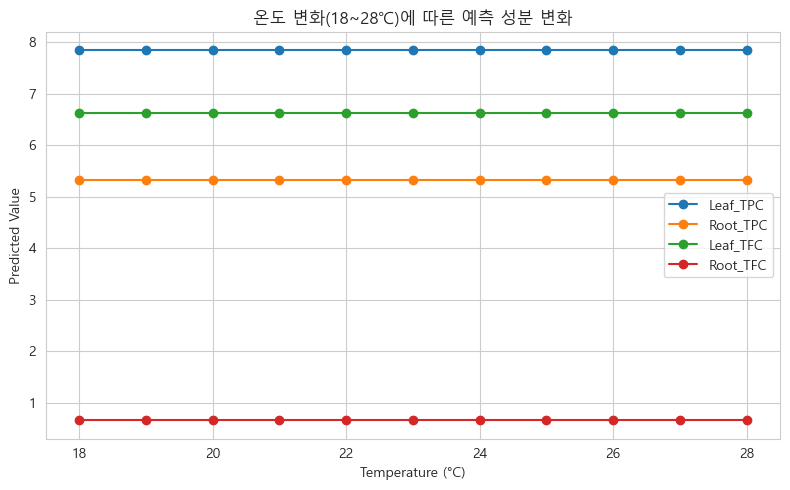


[CO₂ 농도 변화 시뮬레이션]


,CO2ppm,Leaf_TPC,Root_TPC,Leaf_TFC,Root_TFC
0,450,7.839081,5.326063,6.628746,0.658864
1,800,7.839081,5.326063,6.628746,0.658864
2,1150,7.839081,5.326063,6.628746,0.658864


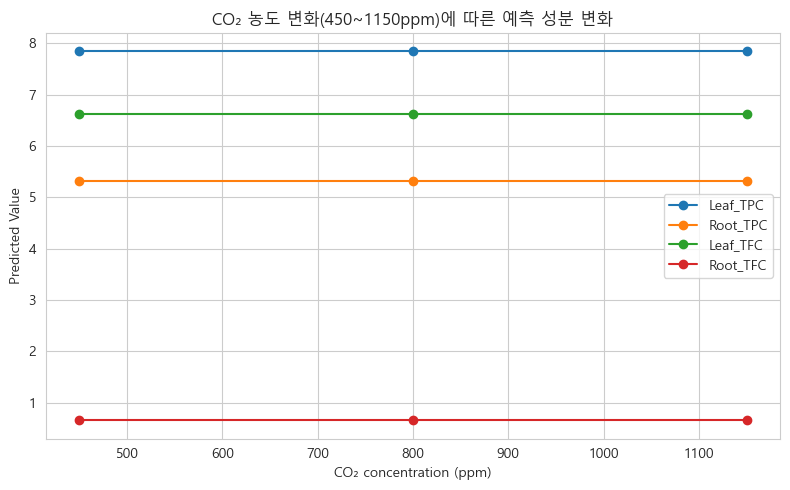


[월(month) 변화 시뮬레이션]


,Month,Leaf_TPC,Root_TPC,Leaf_TFC,Root_TFC
0,5,7.739928,5.487210,5.968664,0.685027
1,6,7.827252,5.332815,6.407942,0.668160
2,7,7.839081,5.326063,6.628746,0.658864
3,8,7.686759,5.052469,4.084438,0.595909
4,9,7.630372,5.095533,3.954532,0.582509


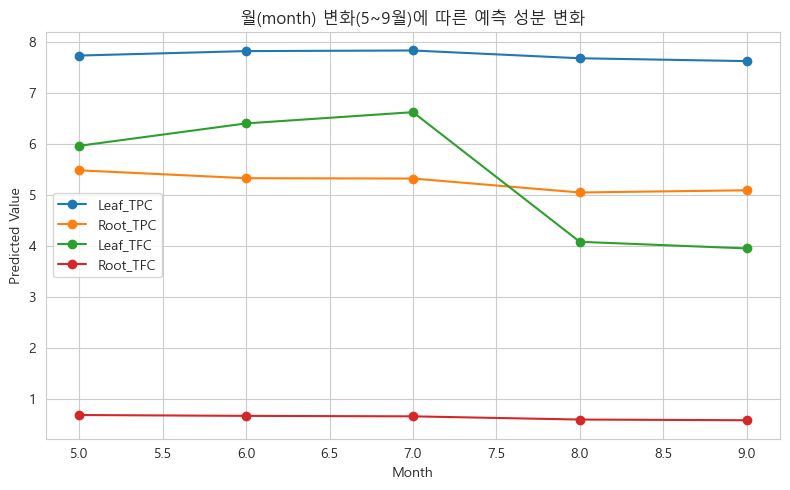


 환경요소(온도·CO₂·월) 변화에 따른 예측 반응 시뮬레이션 완료.


In [9]:
# ===============================================
# DEMO — 환경조건 변화에 따른 예측 반응 시연
# ===============================================

# 윈도우용 한글 폰트 + 마이너스 깨짐 방지
mpl.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 기본 폰트
mpl.rcParams['axes.unicode_minus'] = False

# (1) 기준 조건 설정
base_cond = dict(temp=24, humid=70, co2=800, leaf_yield=15, root_yield=10, month=7)
print("기준 조건:", base_cond)

# (2) 온도 변화 (18~28°C)
print("\n[온도 변화 시뮬레이션 18~28°C]")
df_temp = []
for t in range(18, 29):
    row = make_input_row(t, base_cond["humid"], base_cond["co2"],
                         base_cond["leaf_yield"], base_cond["root_yield"], base_cond["month"])
    pred = final_model.predict(row)[0]
    df_temp.append([t, *pred])
df_temp = pd.DataFrame(df_temp, columns=["Temp"] + targets)
display(df_temp.head())

plt.figure(figsize=(8,5))
for tgt in ["Leaf_TPC","Root_TPC","Leaf_TFC","Root_TFC"]:
    plt.plot(df_temp["Temp"], df_temp[tgt], marker="o", label=tgt)
plt.title("온도 변화(18~28℃)에 따른 예측 성분 변화")
plt.xlabel("Temperature (°C)"); plt.ylabel("Predicted Value")
plt.legend(); plt.tight_layout(); plt.show()

# (3) CO₂ 농도 변화 (450, 800, 1150ppm)
print("\n[CO₂ 농도 변화 시뮬레이션]")
co2_vals = [450, 800, 1150]
rows = []
for c in co2_vals:
    row = make_input_row(base_cond["temp"], base_cond["humid"], c,
                         base_cond["leaf_yield"], base_cond["root_yield"], base_cond["month"])
    pred = final_model.predict(row)[0]
    rows.append([c, *pred])
df_co2 = pd.DataFrame(rows, columns=["CO2ppm"] + targets)
display(df_co2)

plt.figure(figsize=(8,5))
for tgt in ["Leaf_TPC","Root_TPC","Leaf_TFC","Root_TFC"]:
    plt.plot(df_co2["CO2ppm"], df_co2[tgt], marker="o", label=tgt)
plt.title("CO₂ 농도 변화(450~1150ppm)에 따른 예측 성분 변화")
plt.xlabel("CO₂ concentration (ppm)"); plt.ylabel("Predicted Value")
plt.legend(); plt.tight_layout(); plt.show()

# (4) 월(month) 변화 (5~9월)
print("\n[월(month) 변화 시뮬레이션]")
rows = []
for m in range(5,10):
    row = make_input_row(base_cond["temp"], base_cond["humid"], base_cond["co2"],
                         base_cond["leaf_yield"], base_cond["root_yield"], m)
    pred = final_model.predict(row)[0]
    rows.append([m, *pred])
df_month = pd.DataFrame(rows, columns=["Month"] + targets)
display(df_month)

plt.figure(figsize=(8,5))
for tgt in ["Leaf_TPC","Root_TPC","Leaf_TFC","Root_TFC"]:
    plt.plot(df_month["Month"], df_month[tgt], marker="o", label=tgt)
plt.title("월(month) 변화(5~9월)에 따른 예측 성분 변화")
plt.xlabel("Month"); plt.ylabel("Predicted Value")
plt.legend(); plt.tight_layout(); plt.show()

print("\n 환경요소(온도·CO₂·월) 변화에 따른 예측 반응 시뮬레이션 완료.")